# MNIST CNN - 이미지를 "보는" 신경망

# 1. 모듈 불러오기

In [ ]:
# 각종 모듈 불러오기

import os, random
import numpy as np
import tensorflow as tf
import koreanize_matplotlib
import matplotlib.pyplot as plt

# 2. 랜덤시드 고정으로 재연성 확보하기

In [ ]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3-1. 데이터 불러오기

In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()



# 3-2. 데이터 차원 늘리기

In [ ]:
# x_train[0].shape -> (28, 28)
# 맨 앞 -1의 의미는 맨 앞의 수치인 이미지 개수는 알아서 계산해라! 라는 의미
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

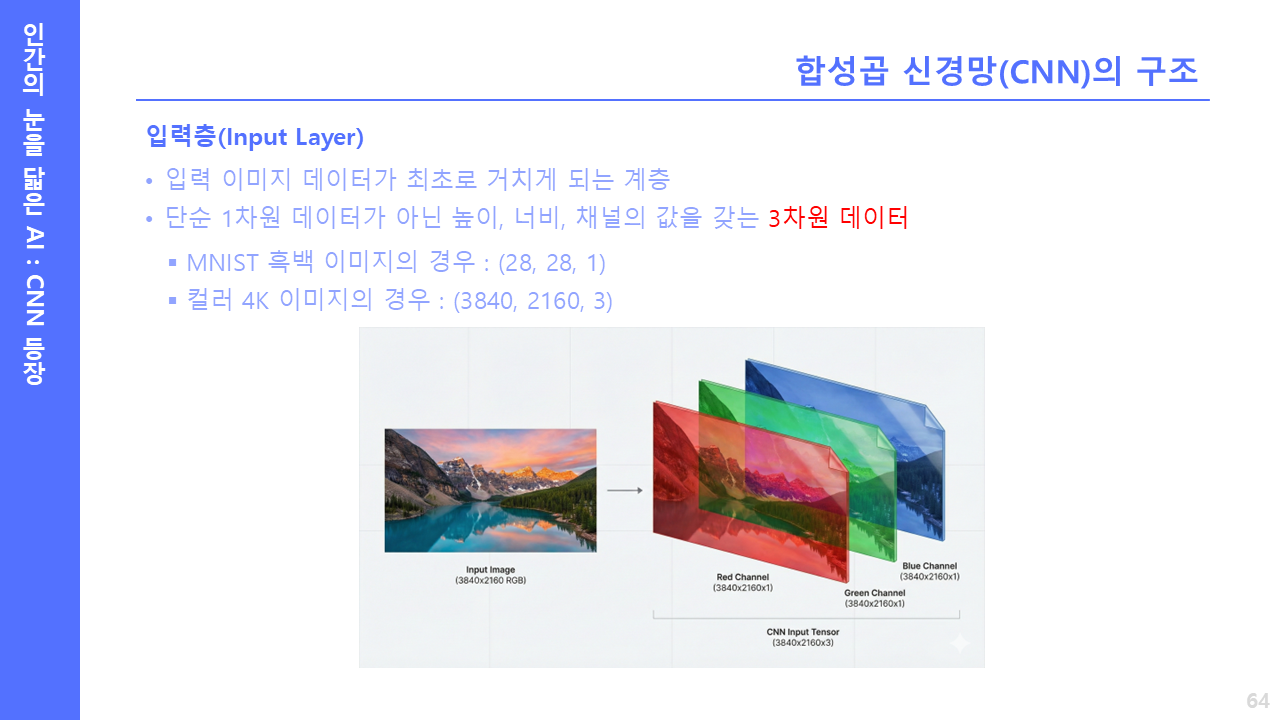

- CNN 입력은 (높이, 너비, 채널)의 3차원 데이터
- 흑백 MNIST는 채널이 1개라서 (28, 28, 1)이 되어야 함.

| 단계 | 모양 | 의미 |
|:---:|:---:|:---:|
| 원본 | (60000, 28, 28) | 이미지 6만 장, 각 28 * 28 |
| 변환 후 | (60000, 28, 28, 1) | 마지막에 채널 차원 1 추가 |

- `reshape(-1, 28, 28, 1)`의 `-1`은 "맨 앞 숫자(이미지 개수)는 알아서 계산해줘"라는 의미

# 4. 데이터 정규화 하기

In [ ]:
# 0 ~ 255 사이의 값을 0 ~ 1 사이의 값으로 만들어 계산을 돕기

x_train, x_test = x_train / 255.0, x_test / 255.0

# 5-1. CNN 구조 설정

In [ ]:
inputs = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(inputs)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPool2D((2, 2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.ReLU()(x)

outputs = tf.keras.layers.Dense(10)(x)
outputs = tf.keras.layers.Softmax()(outputs)

model = tf.keras.Model(inputs, outputs, name='mnist_cnn_baseline')

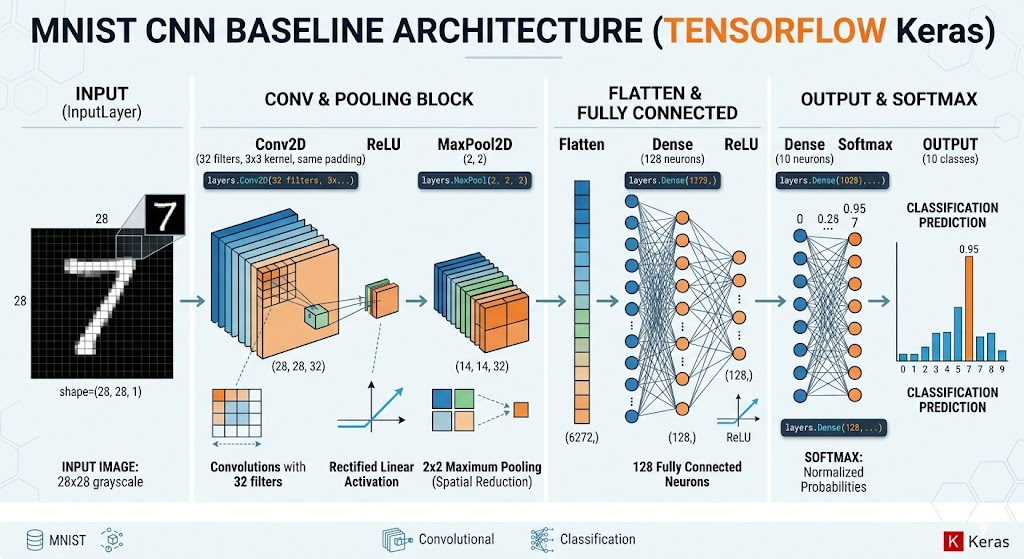

- MLP와 두 가지 큰 차이
>- 작성 방식: Sequential -> Functional API
>> MLP에서는 Sequential([층1, 층2, ...])의 리스트로 쌓았는데, 여기서는 층을 함수처럼 호출해서 x변수에 결과를 받아 이어 붙임. 단순 구조에서는 결과가 같지만, 복잡한 구조(가지치기, 합치기)에선 Functional이 필수
>- 구조 자체: Conv2D + MaxPool2D 등장
>>- `Conv2D(32, (3, 3), padding='same')` - 합성곱층
>>>- `32`: 필터(커널) 32개.
>>>- `(3, 3)`: 필터 크기 3 * 3. 일반적으로 3 * 3 또는 5 * 5사용
>>>- `padding=same`: 출력 크기를 입력과 똑같이 유지. 가장자리에 0을 둘러서(zero padding) 28 * 28을 유지.
>>>- 역할: "특정 모양(패턴)을 찾는 사냥꾼"으로 가로선, 세로선, 곡선 같은 특징을 32가지 방식으로 찾음
>>- `ReLU()` - 활성화 함수
>>>- 음수는 0으로, 양수는 그대로 전달
>>>- MLP에서는 `Dense(128, activation='relu')`처럼 인자로 넣었지만, 여기서는 별도 층으로 분리. 동작은 같음
>>- `MaxPool2D((2, 2))` - 풀링층
>>>- 2 * 2영역에서 최댓값만 남김.
>>>- 효과: 28 * 28 -> 14 * 14로 절반 축소.
>>>- 왜 max? : 평균보다 중요한 특징(강한 신호)을 보존하기 때문
>>- `Flatten()` - 펼치기
>>>- (14, 14, 32) 3차원을 6,272개(=14 * 14 * 32) 1차원 벡터로 펼침
>>>- 공간 정보를 의미 정보(체크리스트)로 바꾸는 과정
>>- `Dense(128) + ReLU() + Dense(10) + Softmax()` - 분류기
>>>- MLP와 동일

# 5-2. CNN 모델 컴파일

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5-3. CNN 모델 요약

In [ ]:
model.summary()

Model: "mnist_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,554 (3.07 MB)

 Trainable params: 804,554 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

- 파라미터 계산표
| 층 | 출력 모양 | 파라미터 계산 | 파라미터 수|
|:---:|:---:|:---:|:---:|
| Input | (None, 28, 28, 1) | - | 0 |
| Conv2D(32) | (None, 28, 28, 1) | (3 * 3 * 1) * 32 + 32 | 320 |
| ReLU | (None, 28, 28, 32) | - | 0 |
|MaxPool2D | (None, 14, 14, 32) | - | 0|
|Flatten|(None, 6272)|14 * 14 * 32 |0 |
|Dense(128)|(None, 128)|6272 * 128 + 128 |802,944|
| ReLU | (None, 128) | - | 0 |
|Dense(10)|(None, 10)|128 * 10 + 10 |1,290|
|Softmax|(None, 10) | - | 0|
|전체|||804,554|
- MLP vs CNN 파라미터 비교 - 의외의 발견
|구분|MLP|CNN|
|:---:|:---:|:---:|
|총 파라미터|101,770개|804,554개|
|첫 Dense 입력 크기|784|6,272|
|합성곱 자체|없음|320개(전체의 0.04%)|
|Flatten 후 Dense|100,480개|802,944개|
>- CNN이 MLP보다 8배 많아 보이지만, 진짜 "이미지를 보는" 합성곱 부분(320개)은 거의 절반 수준. 파라미터의 대부분은 Flatten 다음 Dense에 몰려 있음.
>- CNN의 진짜 강점은 파라미터 공유 - 같은 필터가 이미지 전체를 훑으므로 적은 가중치로 강력한 패턴 인식이 가능하다는 점

# 6. 학습 시작

In [ ]:
history = model.fit(x_train, y_train,
                    validation_split = 0.2,
                    epochs = 30)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9488 - loss: 0.1730 - val_accuracy: 0.9772 - val_loss: 0.0787
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9824 - loss: 0.0586 - val_accuracy: 0.9822 - val_loss: 0.0644
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9893 - loss: 0.0362 - val_accuracy: 0.9845 - val_loss: 0.0594
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9933 - loss: 0.0227 - val_accuracy: 0.9833 - val_loss: 0.0668
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9958 - loss: 0.0150 - val_accuracy: 0.9860 - val_loss: 0.0577
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9964 - loss: 0.0118 - val_accuracy: 0.9850 - val_loss: 0.0617
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9968 - loss: 0.0100 - val_accuracy: 0.9863 - val_loss: 0.0583
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9982 - loss: 0.0061 - 

# 7. 최종 평가

In [ ]:
print("\n========== 최종 테스트 결과 ==========")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n테스트 정확도: {test_acc * 100:.2f}%")


========== 최종 테스트 결과 ==========
313/313 - 1s - 2ms/step - accuracy: 0.9886 - loss: 0.0935

테스트 정확도: 98.86%


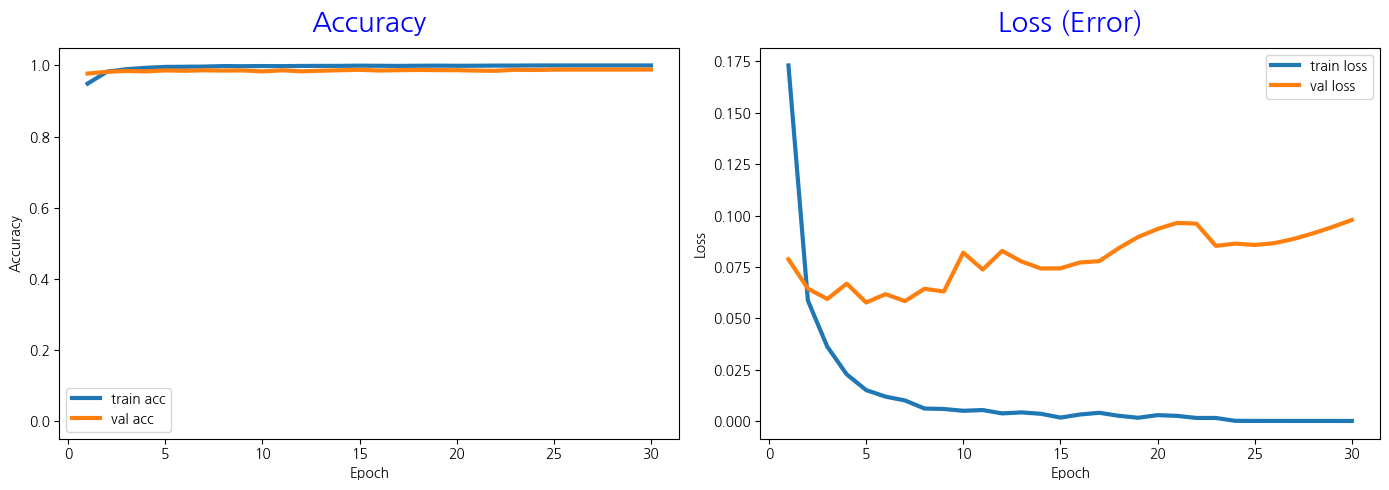

In [ ]:
# 그래프로 확인하기
def plot_history_subplot(history):
    hist = history.history
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 가로 2개

    # =========================
    # (왼쪽) Accuracy
    # =========================
    ax = axes[0]
    ax.plot(epochs, hist["accuracy"], linewidth=3, label="train acc")
    if "val_accuracy" in hist:
        ax.plot(epochs, hist["val_accuracy"], linewidth=3, label="val acc")

    ax.set_title("Accuracy", fontsize=20, color="blue", pad=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

    # =========================
    # (오른쪽) Loss (Error)
    # =========================
    ax = axes[1]
    ax.plot(epochs, hist["loss"], linewidth=3, label="train loss")
    if "val_loss" in hist:
        ax.plot(epochs, hist["val_loss"], linewidth=3, label="val loss")

    ax.set_title("Loss (Error)", fontsize=20, color="blue", pad=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    plt.tight_layout()
    plt.show()

# 학습 후 호출
plot_history_subplot(history)

# 8. 모델 저장

In [ ]:
model.save("mnist_cnn.keras")
print("모델이 mnist_cnn.keras 파일로 저장되었습니다.")

모델이 mnist_cnn.keras 파일로 저장되었습니다.


# 9. 데이터 증강 적용하기

In [ ]:
data_augmentation = tf.keras.Sequential([
    # 좌우 반전 (숫자와 알파벳은 b/d 처럼 의미가 달라질 수 있어 주의 필요, 포트홀엔 필수)
    # tf.keras.layers.RandomFlip("horizontal", seed=SEED),

    # 무작위 회전 (약 20% 범위 내에서 비틀어 보기)
    tf.keras.layers.RandomRotation(0.2, seed=SEED),

    # 무작위 확대/축소 (약 20% 범위 내에서 멀리서/가까이서 보기)
    tf.keras.layers.RandomZoom(0.2, seed=SEED),
])

- 데이터 증강: 인위적인 변화로 데이터 양과 다양성 확보
>- `RandomFlip("horizontal")`: 좌우 반전
>- `RandomRotation(0.2)`: 무작위 회전. 0.2 = 20%의미. 즉 360도의 20%인 -72도 ~ 72도 회전
>- `RandomZoom(0.2)`: 무작위 확대/축소

# 9. 다시 학습

In [ ]:
inputs = tf.keras.Input(shape=(28, 28, 1))

x = data_augmentation(inputs)

x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPool2D((2, 2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.ReLU()(x)

outputs = tf.keras.layers.Dense(10)(x)
outputs = tf.keras.layers.Softmax()(outputs)

model = tf.keras.Model(inputs, outputs, name='mnist_cnn_data_augmented')

- 데이터 증강 층은 학습시에만 동작하고 평가 및 예측 시에는 자동으로 꺼짐
- Dropout과 같은 특성이라 train / test 에서 알아서 다르게 동작

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(x_train, y_train,
                    validation_split = 0.2,
                    epochs = 10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9485 - loss: 0.1705 - val_accuracy: 0.9767 - val_loss: 0.0794
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9825 - loss: 0.0560 - val_accuracy: 0.9804 - val_loss: 0.0710
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9896 - loss: 0.0342 - val_accuracy: 0.9849 - val_loss: 0.0604
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9938 - loss: 0.0217 - val_accuracy: 0.9843 - val_loss: 0.0642
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9959 - loss: 0.0143 - val_accuracy: 0.9847 - val_loss: 0.0605
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9967 - loss: 0.0106 - val_accuracy: 0.9854 - val_loss: 0.0650
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9971 - loss: 0.0088 - val_accuracy: 0.9830 - val_loss: 0.0762
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9979 - loss: 0.0064 - 

In [ ]:
print("\n========== 최종 테스트 결과 ==========")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n테스트 정확도: {test_acc * 100:.2f}%")


========== 최종 테스트 결과 ==========
313/313 - 1s - 2ms/step - accuracy: 0.9866 - loss: 0.0602

테스트 정확도: 98.66%


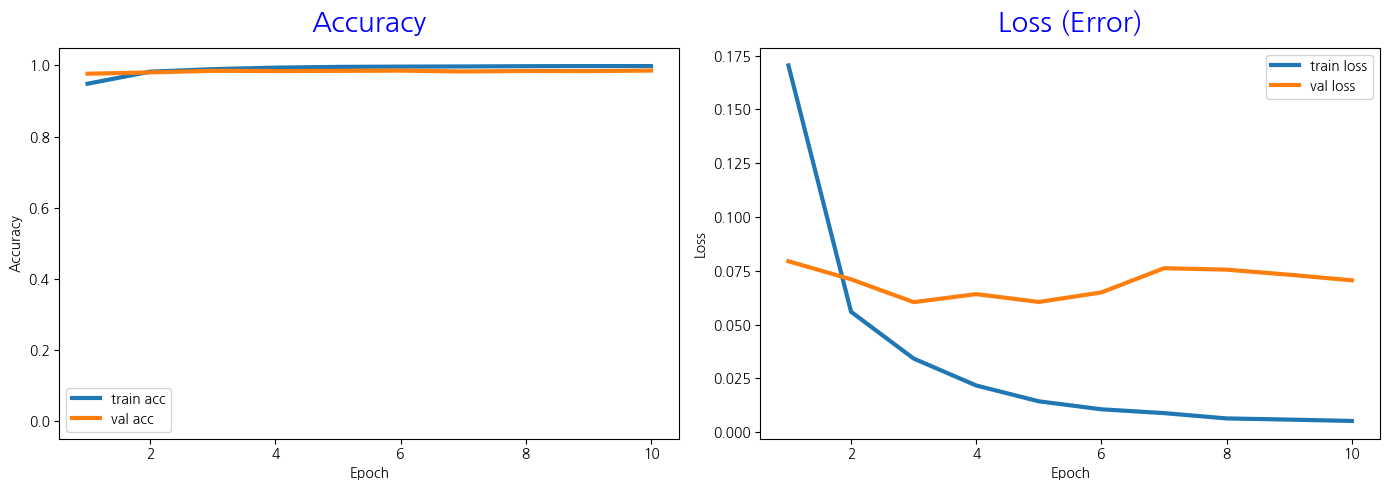

In [ ]:
plot_history_subplot(history)